# Wine Quality Classification - LLM Comparison

Compare three local LLMs (via Ollama) on a 3-class wine quality classification task,
across multiple prompting strategies. The goal is to study how prompt engineering
(few-shot, chain-of-thought, retrieval-augmented exemplars, self-consistency)
affects classification accuracy of off-the-shelf instruction-tuned LLMs.

**Models:**
- Llama 3.1 8B (Meta)
- Qwen 2.5 7B (Alibaba)
- Mistral 7B v0.3 (Mistral AI)

**Prompting strategies:**
- Zero-shot Chain-of-Thought (CoT)
- Few-shot CoT with K=3 random exemplars per class
- Retrieval-Augmented Few-shot CoT (kNN K=5 via SBERT)
- Self-consistency (majority vote of N=3 sampled CoT runs) on the winning model


## 0. Install dependencies

In [4]:
%pip install -q datasets ollama sentence-transformers pandas numpy matplotlib seaborn scipy scikit-learn tqdm

Note: you may need to restart the kernel to use updated packages.


## Pull LLMs via Ollama (one-time)

Run these in PowerShell with `ollama serve` already started in another terminal:

```powershell
ollama pull llama3.1:8b
ollama pull qwen2.5:7b
ollama pull mistral:7b
```

Approximate disk usage: ~13 GB total (each ~4-5 GB at Q4_K_M quantization).
Each model fits comfortably in 8 GB VRAM at this quantization.


## 1. Imports & Configuration

In [5]:
import os, time, re, gc, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from scipy.stats import spearmanr
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    matthews_corrcoef, confusion_matrix,
)
warnings.filterwarnings("ignore")

import ollama

RANDOM_SEED       = 42
N_TEST_EVAL       = 100         
N_RETRIEVAL_POOL  = 3000      
FEWSHOT_K_RANDOM  = 4
RETRIEVAL_K       = 6
SC_NUM_SAMPLES    = 3            
SC_TEMPERATURE    = 0.6
NUM_CLASSES       = 3
CLASS_NAMES       = ["Low", "Medium", "High"]

LLM_MODELS = [
    ("qwen2.5:14b", "Qwen-2.5-14B"),
    ("mistral-nemo:12b", "Mistral-Nemo-12B"),
    ("gemma3:12b", "Gemma-3-12B"),
]

OLLAMA_OPTIONS_DETERMINISTIC = {
    "temperature": 0.0,
    "num_predict": 8,
    "top_p":       1.0,
}

OLLAMA_OPTIONS_SAMPLED = {
    "temperature": SC_TEMPERATURE,
    "num_predict": 4,
    "top_p":       0.95,
}

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

print("Ollama version:", ollama.__version__ if hasattr(ollama, "__version__") else "unknown")
print(f"Eval test size : {N_TEST_EVAL}")
print(f"Retrieval pool : {N_RETRIEVAL_POOL}")
print(f"Models         : {[name for _, name in LLM_MODELS]}")


Ollama version: unknown
Eval test size : 100
Retrieval pool : 3000
Models         : ['Qwen-2.5-14B', 'Mistral-Nemo-12B', 'Gemma-3-12B']


## 2. Data Loading

`james-burton/wine_reviews_ordinal` (Burton 2023) - WineMag corpus reformulated for ordinal
classification, with predefined train / val / test splits.


In [6]:
from datasets import load_dataset

ds = load_dataset("james-burton/wine_reviews_ordinal")
train_raw = ds["train"].to_pandas()
test_raw  = ds["test"].to_pandas()

print(f"Train: {len(train_raw):,} | Test: {len(test_raw):,}")

def normalise(df):
    df = df.rename(columns={
        "description": "review",
        "points":      "rating",
        "province":    "region",
    }).copy()
    df = df.dropna(subset=["rating", "review"]).reset_index(drop=True)
    df = df[df["review"].astype(str).str.strip().str.len() > 10].reset_index(drop=True)
    df["price"]   = pd.to_numeric(df["price"], errors="coerce")
    df["country"] = df["country"].fillna("Unknown").astype(str)
    df["region"]  = df["region"].fillna("Unknown").astype(str)
    return df

train_df = normalise(train_raw)
test_df  = normalise(test_raw)
print(f"After cleaning - Train: {len(train_df):,} | Test: {len(test_df):,}")
train_df.head(2)

Train: 71,504 | Test: 21,031
After cleaning - Train: 71,504 | Test: 21,031


,country,review,rating,price,region,variety
0,France,"Although it's not indicated on the label, this...",92,NaN,Champagne,5
1,US,"A touch salty on the entry, this wine offers s...",84,17.0,California,5


## 3. Tertile Binning

Quality scores (80-100) are partitioned into 3 ordinal classes (Low / Medium / High)
using percentile cut-offs from the training distribution.


In [7]:
bins = [80, 82, 90, 100]

def make_label(rating):
    if rating <= 82:
        return 0
    elif rating <= 90:
        return 1
    else:
        return 2


train_df["label"] = train_df["rating"].apply(make_label)
test_df["label"]  = test_df["rating"].apply(make_label)

print(f"\nBin edges: {bins}")

print("\nTrain class distribution:")
print(
    train_df["label"]
    .value_counts(normalize=True)
    .sort_index()
    .round(3)
    .to_dict()
)

print("\nTest class distribution:")
print(
    test_df["label"]
    .value_counts(normalize=True)
    .sort_index()
    .round(3)
    .to_dict()
)

print("\nClass definitions:")
print(f"Class 0: 80 <= rating <= 82")
print(f"Class 1: 82 < rating <= 90")
print(f"Class 2: 90 < rating <= 100")


Bin edges: [80, 82, 90, 100]

Train class distribution:
{0: 0.023, 1: 0.703, 2: 0.274}

Test class distribution:
{0: 0.021, 1: 0.703, 2: 0.275}

Class definitions:
Class 0: 80 <= rating <= 82
Class 1: 82 < rating <= 90
Class 2: 90 < rating <= 100


## 4. Sample Test Subset + Retrieval Pool

A deterministic, class-stratified subset of 100 test reviews keeps total runtime
manageable (3 LLMs × 3 strategies × 100 calls).

A class-stratified subsample of 5000 training reviews serves as the retrieval pool
for the kNN exemplar-selection strategy.


In [ ]:
def stratified_subsample(df, n, seed=RANDOM_SEED):
    parts = []
    class_counts = df["label"].value_counts(normalize=True)
    for k, prop in class_counts.items():
        g = df[df["label"] == k]
        n_k = max(1, round(n * prop))
        parts.append(g.sample(n=min(n_k, len(g)), random_state=seed))
    out = pd.concat(parts, ignore_index=True)
    return out.sample(frac=1, random_state=seed).reset_index(drop=True)


test_eval_df = stratified_subsample(test_df, N_TEST_EVAL)
retrieval_pool = stratified_subsample(train_df, N_RETRIEVAL_POOL)

print(f"\nTest eval subset size: {len(test_eval_df)}")
print("Test class distribution:")
print(test_eval_df["label"].value_counts().sort_index().to_dict())

print(f"\nRetrieval pool size: {len(retrieval_pool)}")
print("Pool class distribution:")
print(retrieval_pool["label"].value_counts().sort_index().to_dict())


Test eval subset size: 100
Test class distribution:
{0: 2, 1: 70, 2: 28}

Retrieval pool size: 3000
Pool class distribution:
{0: 68, 1: 2110, 2: 822}


## 5. SBERT Embeddings (for retrieval-augmented few-shot)

Encode the retrieval pool and test subset with `all-mpnet-base-v2`. L2-normalized
embeddings allow cosine similarity to be computed as a simple dot product.


In [9]:
from sentence_transformers import SentenceTransformer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "BAAI/bge-large-en-v1.5"
# model_name = "BAAI/bge-small-en-v1.5"
sbert = SentenceTransformer(model_name, device=device)

print(f"Model: {model_name}")
print(f"Device: {device}")
print(f"Embedding dim: {sbert.get_sentence_embedding_dimension()}")

retrieval_pool["review"] = retrieval_pool["review"].fillna("")
test_eval_df["review"] = test_eval_df["review"].fillna("")

print("Encoding retrieval pool...")
pool_emb = sbert.encode(
    retrieval_pool["review"].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Encoding test set...")
test_emb = sbert.encode(
    test_eval_df["review"].tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

del sbert
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Pool embeddings : {pool_emb.shape}")
print(f"Test embeddings : {test_emb.shape}")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Model: BAAI/bge-large-en-v1.5
Device: cuda
Embedding dim: 1024
Encoding retrieval pool...


Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Encoding test set...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Pool embeddings : (3000, 1024)
Test embeddings : (100, 1024)


## 6. Prompt Templates

We use a unified system prompt across all experimental strategies, combined with three exemplar selection schemes: zero-shot, random few-shot, and retrieval-augmented few-shot.

The model is instructed to perform ordinal wine quality classification and to output exactly one label: 0 (low), 1 (medium), or 2 (high). No structured output format (e.g., JSON) is used in order to avoid format instability across different LLMs.

This design improves robustness and ensures consistent evaluation across models that may not strictly follow structured output instructions.

In [10]:
def class_description():
    return (
        "Wine quality classes:\n"
        "0 = low quality wine (simple, thin, diluted, harsh, short finish, unbalanced)\n"
        "1 = medium quality wine (pleasant, balanced, correct, good everyday wine)\n"
        "2 = high quality wine (complex, layered, elegant, concentrated, structured, long finish)"
    )

CLASS_RANGES = class_description()

SYSTEM_PROMPT = (
    "You are a professional wine judge.\n"
    "You must classify wines into exactly one class.\n\n"

    f"{CLASS_RANGES}\n\n"

    "Guidelines:\n"
    "- Class 0 is rare: only for clearly weak, thin, harsh or unbalanced wines\n"
    "- Class 2 is for exceptional wines: complex, structured, long finish\n"
    "- Expensive wines (over 50 USD) are likely class 2\n"
    "- If price is unknown, lean toward class 1 unless the review is clearly exceptional\n"
    "- Enthusiastic language (outstanding, gorgeous, profound, stunning, beautiful) suggests class 2\n"
    "- Thin, watery, sharp or overly simple language suggests class 0\n"
    "- Renowned regions (Burgundy, Bordeaux, Napa, Barolo, Champagne) are more often class 2\n"
    "- Focus on overall quality impression, not isolated words\n\n"

    "CRITICAL RULES:\n"
    "- Output ONLY one digit: 0, 1, or 2\n"
    "- No explanation\n"
    "- No punctuation\n"
    "- No extra text"
)


def format_wine(row):
    price_str = f"{row['price']:.0f} USD" if pd.notna(row['price']) else "unknown"
    return (
        f"Country: {row['country']} | Region: {row['region']} | Price: {price_str}\n"
        f"Review: {str(row['review'])[:300]}"
    )


def format_exemplar(row):
    return f"{format_wine(row)}\nClass: {int(row['label'])}"


def build_prompt_zeroshot(test_row):
    user = (
        "Classify this wine.\n"
        "Return ONLY one digit: 0, 1, or 2.\n\n"
        f"{format_wine(test_row)}"
    )
    return SYSTEM_PROMPT, user


def build_prompt_fewshot_random(test_row, rng):
    examples = []
    for k in range(NUM_CLASSES):
        pool = retrieval_pool[retrieval_pool["label"] == k]
        idx = rng.choice(len(pool), size=FEWSHOT_K_RANDOM, replace=False)
        for i in idx:
            examples.append(format_exemplar(pool.iloc[i]))
    rng.shuffle(examples)

    user = (
        "Labeled wine examples:\n\n"
        + "\n\n".join(examples)
        + "\n\n"
        "Now classify the final wine.\n\n"
        f"{format_wine(test_row)}\n\n"
        "Return ONLY: 0, 1, or 2"
    )
    return SYSTEM_PROMPT, user


def build_prompt_retrieval(test_row, test_idx):
    sims = pool_emb @ test_emb[test_idx]
    examples = []
    per_class = max(1, RETRIEVAL_K // NUM_CLASSES)
    for k in range(NUM_CLASSES):
        mask = retrieval_pool["label"].values == k
        class_sims = sims.copy()
        class_sims[~mask] = -np.inf
        top = np.argsort(-class_sims)[:per_class]
        for i in top:
            examples.append(format_exemplar(retrieval_pool.iloc[i]))
    
    rng = np.random.RandomState(test_idx)
    rng.shuffle(examples)

    user = (
        "Similar wines for reference:\n\n"
        + "\n\n".join(examples)
        + "\n\n"
        "Now classify the final wine based on its own merits.\n\n"
        f"{format_wine(test_row)}\n\n"
        "Return ONLY one digit: 0, 1, or 2"
    )
    return SYSTEM_PROMPT, user

## 7. LLM Runner + Robust Output Parsing

We send chat requests to Ollama and extract the predicted label from the model output.

Since models exhibit format drift (e.g., returning JSON, plain text, or mixed formats), we do not enforce structured outputs. Instead, we use a simple and robust parsing strategy that extracts the first valid class label (0, 1, or 2) from the response.

Parse failures are rare and are handled by assigning a default class (medium = 1), and are tracked separately for analysis.

In [11]:
def parse_label(text):
    if not text:
        return None

    text = str(text).strip()

    if text in {"0", "1", "2"}:
        return int(text)

    import re
    m = re.search(r"\b[012]\b", text)
    if m:
        return int(m.group(0))

    return None

def call_llm(model, system, user, options=None):
    if options is None:
        options = OLLAMA_OPTIONS_DETERMINISTIC

    try:
        resp = ollama.chat(
            model=model,
            messages=[
                {"role": "system", "content": system},
                {"role": "user", "content": user}
            ],
            options=options,
        )
        return resp["message"]["content"]

    except Exception as e:
        return ""

def evaluate_strategy(model_name, model_id, strategy, test_subset,
                      options=None):

    rng_local = np.random.RandomState(RANDOM_SEED)

    preds, true, raw_outputs = [], [], []
    parse_failures = 0

    t0 = time.time()

    desc = f"{model_name:>16s} | {strategy:<14s}"

    for i, (_, row) in enumerate(tqdm(
            test_subset.iterrows(),
            total=len(test_subset),
            desc=desc)):
        
        if strategy == "zero_shot":
            sys_p, user_p = build_prompt_zeroshot(row)

        elif strategy == "fewshot_random":
            sys_p, user_p = build_prompt_fewshot_random(row, rng_local)

        elif strategy == "retrieval":
            sys_p, user_p = build_prompt_retrieval(row, i)

        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        out = call_llm(model_id, sys_p, user_p, options=options)
        raw_outputs.append(out)

        pred = parse_label(out)

        if pred is None:
            parse_failures += 1
            pred = 1

        preds.append(pred)
        true.append(int(row["label"]))

        if i < 3:
            print("RAW:", out)
            print("PRED:", pred)
            print("TRUE:", row["label"])

    elapsed = time.time() - t0

    return {
        "model": model_name,
        "model_id": model_id,
        "strategy": strategy,
        "preds": np.array(preds),
        "labels": np.array(true),
        "raw": raw_outputs,
        "parse_failures": parse_failures,
        "elapsed_s": elapsed,
    }

## 7b. Quick Sanity Check

Issue one prompt to each model to confirm Ollama is reachable and the model is
loaded into VRAM. If a model fails here, pull it via `ollama pull <name>`.


In [12]:
for model_id, model_name in LLM_MODELS:
    try:
        sys_p, user_p = build_prompt_zeroshot(test_eval_df.iloc[0])
        t0  = time.time()
        out = call_llm(model_id, sys_p, user_p)
        dt  = time.time() - t0
        pred = parse_label(out)
        true = int(test_eval_df.iloc[0]["label"])
        print(f"[OK] {model_name:<18s} latency={dt:.1f}s  pred={pred}  true={true}")
        print(f"     raw: {out[:200]!r}")
    except Exception as e:
        print(f"[ERR] {model_name}: {e}")


[OK] Qwen-2.5-14B       latency=1.4s  pred=None  true=2
     raw: ''
[OK] Mistral-Nemo-12B   latency=8.2s  pred=2  true=2
     raw: '2'
[OK] Gemma-3-12B        latency=1.4s  pred=None  true=2
     raw: ''


## 8. Main Sweep: 3 Models × 3 Strategies

In [13]:
STRATEGIES = ["zero_shot", "fewshot_random", "retrieval"]
all_runs = []

for model_id, model_name in LLM_MODELS:
    for strategy in STRATEGIES:
        run = evaluate_strategy(model_name, model_id, strategy, test_eval_df)
        acc = accuracy_score(run["labels"], run["preds"])
        print(f"--> {model_name:<18s} {strategy:<14s}  acc={acc:.4f}  "
               f"parse_fails={run['parse_failures']:3d}/{len(test_eval_df)}  "
               f"time={run['elapsed_s']/60:.1f}min")
        all_runs.append(run)


    Qwen-2.5-14B | zero_shot     :   0%|          | 0/100 [00:00<?, ?it/s]

RAW: 2
PRED: 2
TRUE: 2
RAW: 1
PRED: 1
TRUE: 1
RAW: 2
PRED: 2
TRUE: 2
--> Qwen-2.5-14B       zero_shot       acc=0.7600  parse_fails=  0/100  time=1.3min


    Qwen-2.5-14B | fewshot_random:   0%|          | 0/100 [00:00<?, ?it/s]

RAW: 1
PRED: 1
TRUE: 2
RAW: 1
PRED: 1
TRUE: 1
RAW: 2
PRED: 2
TRUE: 2
--> Qwen-2.5-14B       fewshot_random  acc=0.6500  parse_fails=  0/100  time=3.4min


    Qwen-2.5-14B | retrieval     :   0%|          | 0/100 [00:00<?, ?it/s]

...

RAW: 2
PRED: 2
TRUE: 2
RAW: 1
PRED: 1
TRUE: 1
RAW: 2
PRED: 2
TRUE: 2
--> Gemma-3-12B        zero_shot       acc=0.8000  parse_fails=  0/100  time=1.3min


     Gemma-3-12B | fewshot_random:   0%|          | 0/100 [00:00<?, ?it/s]

RAW: 2
PRED: 2
TRUE: 2
RAW: 1
PRED: 1
TRUE: 1
RAW: 2
PRED: 2
TRUE: 2
--> Gemma-3-12B        fewshot_random  acc=0.8000  parse_fails=  0/100  time=3.4min


     Gemma-3-12B | retrieval     :   0%|          | 0/100 [00:00<?, ?it/s]

RAW: 2
PRED: 2
TRUE: 2
RAW: 1
PRED: 1
TRUE: 1
RAW: 2
PRED: 2
TRUE: 2
--> Gemma-3-12B        retrieval       acc=0.8200  parse_fails=  0/100  time=2.0min


## 9. Self-Consistency Bonus on the Best (Model, Strategy)

For the highest-scoring (model, strategy) pair, draw N=3 sampled completions per
test instance (temperature 0.6) and take the majority vote. This typically lifts
accuracy by 1-3 points by averaging out single-shot stochasticity.


In [14]:
best_run = max(all_runs, key=lambda r: accuracy_score(r["labels"], r["preds"]))
print(f"Best so far: {best_run['model']} + {best_run['strategy']} -> "
      f"acc {accuracy_score(best_run['labels'], best_run['preds']):.4f}")

print(f"\nRunning self-consistency (N={SC_NUM_SAMPLES} samples per item)...")

rng_sc = np.random.RandomState(RANDOM_SEED)

sc_preds, sc_true, sc_failures = [], [], 0

t0 = time.time()

for i, (_, row) in enumerate(tqdm(test_eval_df.iterrows(),
                                  total=len(test_eval_df),
                                  desc="self-consistency")):

    if best_run["strategy"] == "zero_shot":
        sys_p, user_p = build_prompt_zeroshot(row)

    elif best_run["strategy"] == "fewshot_random":
        sys_p, user_p = build_prompt_fewshot_random(row, rng_sc)

    else:
        sys_p, user_p = build_prompt_retrieval(row, i)

    user_p = user_p + "\n\nIMPORTANT: Re-evaluate carefully and output only 0, 1, or 2."

    samples = []

    for _ in range(SC_NUM_SAMPLES):
        out = call_llm(
            best_run["model_id"],
            sys_p,
            user_p,
            options=OLLAMA_OPTIONS_SAMPLED
        )

        pred = parse_label(out)

        if pred is not None:
            samples.append(pred)

    if len(samples) == 0:
        sc_failures += 1
        majority = NUM_CLASSES // 2
    else:
        majority = Counter(samples).most_common(1)[0][0]

    sc_preds.append(majority)
    sc_true.append(int(row["label"]))

sc_run = {
    "model": best_run["model"] + " (SC)",
    "model_id": best_run["model_id"],
    "strategy": best_run["strategy"] + "_sc",
    "preds": np.array(sc_preds),
    "labels": np.array(sc_true),
    "raw": None,
    "parse_failures": sc_failures,
    "elapsed_s": time.time() - t0,
}

all_runs.append(sc_run)

print(f"\nSelf-consistency acc: {accuracy_score(sc_run['labels'], sc_run['preds']):.4f}  "
      f"(time {sc_run['elapsed_s']/60:.1f}min)")

Best so far: Mistral-Nemo-12B + retrieval -> acc 0.9000

Running self-consistency (N=3 samples per item)...


self-consistency:   0%|          | 0/100 [00:00<?, ?it/s]


Self-consistency acc: 0.8700  (time 2.6min)


## 10. Compute Metrics

For each run we compute:
- Accuracy
- F1 weighted / macro
- Cohen's kappa (chance-corrected agreement)
- MCC (Matthews correlation, balanced under class imbalance)
- Ordinal MAE (penalizes far-off mistakes more than near-off)
- Rank Accuracy +-1 (fraction within one ordinal step of truth)
- Spearman rho (rank correlation)


In [15]:
def compute_metrics(run):
    y_true = np.asarray(run["labels"], dtype=int).ravel()
    y_pred = np.asarray(run["preds"],  dtype=int).ravel()
    spearman = float(spearmanr(y_true, y_pred).statistic) if len(np.unique(y_pred)) > 1 else 0.0
    return {
        "model":         run["model"],
        "strategy":      run["strategy"],
        "accuracy":      accuracy_score(y_true, y_pred),
        "f1_weighted":   f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_macro":      f1_score(y_true, y_pred, average="macro",    zero_division=0),
        "cohen_kappa":   cohen_kappa_score(y_true, y_pred),
        "mcc":           matthews_corrcoef(y_true, y_pred),
        "mae_ordinal":   float(np.mean(np.abs(y_true - y_pred))),
        "rank_acc_pm1":  float(np.mean(np.abs(y_true - y_pred) <= 1)),
        "spearman_rho":  spearman,
        "parse_fails":   run["parse_failures"],
        "elapsed_min":   round(run["elapsed_s"] / 60, 1),
    }

results_df = pd.DataFrame([compute_metrics(r) for r in all_runs])                 .sort_values("accuracy", ascending=False)                 .reset_index(drop=True)
display(results_df.round(4))


,model,strategy,accuracy,f1_weighted,f1_macro,cohen_kappa,mcc,mae_ordinal,rank_acc_pm1,spearman_rho,parse_fails,elapsed_min
0,Mistral-Nemo-12B,retrieval,0.90,0.8980,0.8514,0.7602,0.7646,0.10,1.0,0.7828,0,59.8
1,Mistral-Nemo-12B (SC),retrieval_sc,0.87,0.8692,0.8285,0.6974,0.6979,0.13,1.0,0.7169,0,2.6
2,Mistral-Nemo-12B,zero_shot,0.83,0.8310,0.6734,0.6043,0.6047,0.17,1.0,0.6462,0,8.8
3,Gemma-3-12B,retrieval,0.82,0.8372,0.6764,0.6207,0.6286,0.18,1.0,0.7107,0,2.0
4,Mistral-Nemo-12B,fewshot_random,0.81,0.8248,0.6782,0.6079,0.6189,0.19,1.0,0.6880,0,109.2
5,Gemma-3-12B,fewshot_random,0.80,0.8210,0.6575,0.5951,0.6093,0.20,1.0,0.6968,0,3.4
6,Gemma-3-12B,zero_shot,0.80,0.8116,0.6796,0.5814,0.5897,0.20,1.0,0.6516,0,1.3
7,Qwen-2.5-14B,zero_shot,0.76,0.7811,0.6314,0.5451,0.5775,0.24,1.0,0.6578,0,1.3
8,Qwen-2.5-14B,retrieval,0.74,0.7611,0.6141,0.4992,0.5234,0.26,1.0,0.6101,0,2.5
9,Qwen-2.5-14B,fewshot_random,0.65,0.6902,0.5331,0.3853,0.4229,0.35,1.0,0.5805,0,3.4


## 11. Comparison Plots

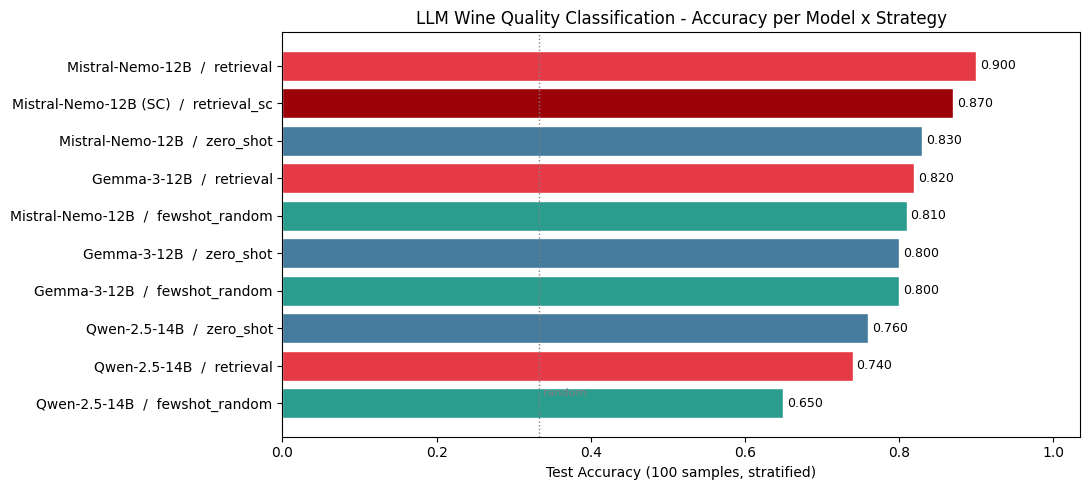

In [20]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_df = results_df.copy()
plot_df["combo"] = plot_df["model"] + "  /  " + plot_df["strategy"]
plot_df = plot_df.sort_values("accuracy", ascending=True)

colors = {"zero_shot": "#457b9d", "fewshot_random": "#2a9d8f",
           "retrieval": "#e63946", "zero_shot_sc": "#1d3557",
           "fewshot_random_sc": "#264653", "retrieval_sc": "#9d0208"}
bar_colors = [colors.get(s, "#888888") for s in plot_df["strategy"]]
ax.barh(plot_df["combo"], plot_df["accuracy"], color=bar_colors, edgecolor="white")
for i, v in enumerate(plot_df["accuracy"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, max(plot_df["accuracy"]) * 1.15)
ax.set_xlabel("Test Accuracy (100 samples, stratified)")
ax.set_title("LLM Wine Quality Classification - Accuracy per Model x Strategy")
ax.axvline(1 / NUM_CLASSES, color="gray", linestyle=":", linewidth=1)
ax.text(1 / NUM_CLASSES + 0.005, 0.2, "random", color="gray", fontsize=8)
plt.tight_layout()
plt.savefig("llm_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


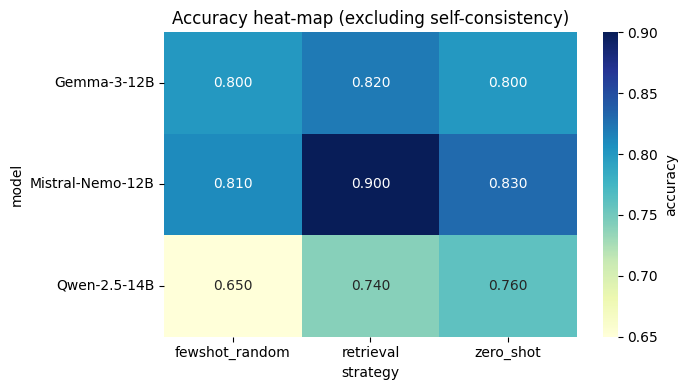

In [17]:
pivot = (results_df[~results_df["strategy"].str.endswith("_sc")]
         .pivot(index="model", columns="strategy", values="accuracy"))
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax,
             cbar_kws={"label": "accuracy"})
ax.set_title("Accuracy heat-map (excluding self-consistency)")
plt.tight_layout()
plt.savefig("llm_accuracy_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 12. Confusion Matrices

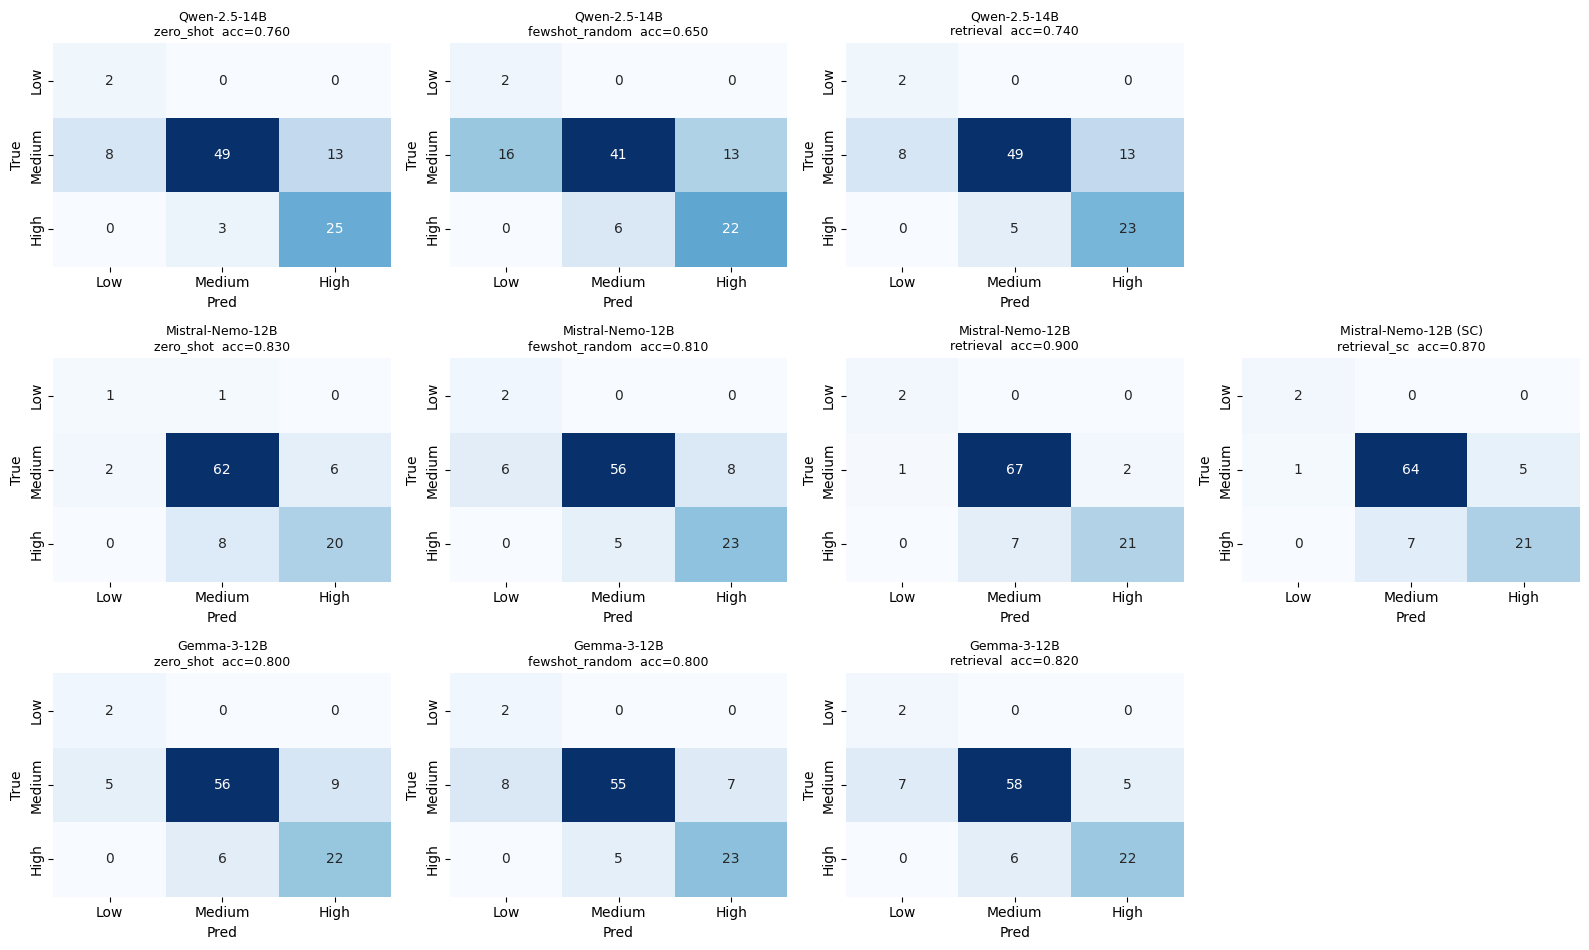

In [18]:
fig, axes = plt.subplots(len(LLM_MODELS), len(STRATEGIES) + (1 if any(r['strategy'].endswith('_sc') for r in all_runs) else 0),
                          figsize=(4 * (len(STRATEGIES) + 1), 3.2 * len(LLM_MODELS)))

if axes.ndim == 1:
    axes = axes.reshape(1, -1)

strategies_full = STRATEGIES + ([best_run["strategy"] + "_sc"] if all_runs[-1]["strategy"].endswith("_sc") else [])
strategy_to_col = {s: i for i, s in enumerate(strategies_full)}
model_to_row    = {name: i for i, (_, name) in enumerate(LLM_MODELS)}
model_to_row[best_run["model"] + " (SC)"] = model_to_row[best_run["model"]]

for ax in axes.flat:
    ax.axis("off")

for run in all_runs:
    base_model_name = run["model"].replace(" (SC)", "")
    if base_model_name not in model_to_row or run["strategy"] not in strategy_to_col:
        continue
    if "(SC)" in run["model"]:
        col = strategy_to_col.get(run["strategy"], len(STRATEGIES))
    else:
        col = strategy_to_col[run["strategy"]]
    row = model_to_row[base_model_name]
    ax = axes[row, col]
    ax.axis("on")
    cm = confusion_matrix(run["labels"], run["preds"], labels=list(range(NUM_CLASSES)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                 xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False)
    acc = accuracy_score(run["labels"], run["preds"])
    ax.set_title(f"{run['model']}\n{run['strategy']}  acc={acc:.3f}", fontsize=9)
    ax.set_xlabel("Pred")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig("llm_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## 13. Save Results

In [19]:
results_df.round(4).to_csv("llm_results.csv", index=False)
print("Saved: llm_results.csv")
print("Saved: llm_accuracy_comparison.png")
print("Saved: llm_accuracy_heatmap.png")
print("Saved: llm_confusion_matrices.png")

import pickle
serialisable = []
for r in all_runs:
    serialisable.append({
        "model":          r["model"],
        "strategy":       r["strategy"],
        "preds":          r["preds"].tolist(),
        "labels":         r["labels"].tolist(),
        "raw":            r["raw"][:50] if isinstance(r["raw"], list) else None,
        "parse_failures": r["parse_failures"],
        "elapsed_s":      r["elapsed_s"],
    })
with open("llm_runs.pkl", "wb") as f:
    pickle.dump(serialisable, f)
print("Saved: llm_runs.pkl  (runs metadata + first 50 raw outputs per run)\n")

latex_cols = ["model", "strategy", "accuracy", "f1_weighted", "cohen_kappa",
               "mcc", "mae_ordinal", "rank_acc_pm1", "spearman_rho"]
print(results_df[latex_cols].round(4).to_latex(index=False, escape=True))


Saved: llm_results.csv
Saved: llm_accuracy_comparison.png
Saved: llm_accuracy_heatmap.png
Saved: llm_confusion_matrices.png
Saved: llm_runs.pkl  (runs metadata + first 50 raw outputs per run)

\begin{tabular}{llrrrrrrr}
\toprule
model & strategy & accuracy & f1\_weighted & cohen\_kappa & mcc & mae\_ordinal & rank\_acc\_pm1 & spearman\_rho \\
\midrule
Mistral-Nemo-12B & retrieval & 0.900000 & 0.898000 & 0.760200 & 0.764600 & 0.100000 & 1.000000 & 0.782800 \\
Mistral-Nemo-12B (SC) & retrieval\_sc & 0.870000 & 0.869200 & 0.697400 & 0.697900 & 0.130000 & 1.000000 & 0.716900 \\
Mistral-Nemo-12B & zero\_shot & 0.830000 & 0.831000 & 0.604300 & 0.604700 & 0.170000 & 1.000000 & 0.646200 \\
Gemma-3-12B & retrieval & 0.820000 & 0.837200 & 0.620700 & 0.628600 & 0.180000 & 1.000000 & 0.710700 \\
Mistral-Nemo-12B & fewshot\_random & 0.810000 & 0.824800 & 0.607900 & 0.618900 & 0.190000 & 1.000000 & 0.688000 \\
Gemma-3-12B & fewshot\_random & 0.800000 & 0.821000 & 0.595100 & 0.609300 & 0.200000 & 1.00